In [528]:
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

In [529]:
infile = r"C:\Users\seifert\Pictures\Temp\Out\ResultTotal_5\res.csv"
df = pd.read_csv(infile, sep=';')

In [530]:
d = dict(df)

In [531]:
d.keys()

dict_keys(['Unnamed: 0', 'total_id', 'img_id', 'crop_id', 'img_fn', 'crop_fn', 'p1', 'p2', 'cat', 'conf', 'w_px', 'h_px', 'mid_x_nm', 'mid_y_nm', 'centroid_x_nm', 'centroid_y_nm', 'NN1_nm', 'NN2_nm', 'NN3_nm', 'NN4_nm', 'NN5_nm', 'area', 'area_nm', 'span_x_nm', 'span_y_nm', 'long_axis_nm', 'short_axis_nm', 'angle'])

In [532]:
%matplotlib inline

In [533]:
ids = np.unique(d['img_id'])

In [534]:
def get_dict_from_id(img_id):
    retd = {}
    idcs = []
    for num, i in tqdm(enumerate(d['img_id'])):
        if i == img_id:
            idcs.append(num)

    for key in d.keys():
        retd[key] = []
        for num, val in enumerate(d[key]):
            if num in idcs:
                retd[key].append(val)


    return retd

In [535]:
dict_0 = get_dict_from_id(100)

2256it [00:00, ?it/s]


In [536]:
dict_0

{'Unnamed: 0': [2190,
  2191,
  2192,
  2193,
  2194,
  2195,
  2196,
  2197,
  2198,
  2199,
  2200,
  2201,
  2202,
  2203,
  2204,
  2205,
  2206,
  2207,
  2208,
  2209],
 'total_id': [2190,
  2191,
  2192,
  2193,
  2194,
  2195,
  2196,
  2197,
  2198,
  2199,
  2200,
  2201,
  2202,
  2203,
  2204,
  2205,
  2206,
  2207,
  2208,
  2209],
 'img_id': [100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100,
  100],
 'crop_id': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19],
 'img_fn': ['C:\\Users\\seifert\\Pictures\\Temp\\DataLib\\Data library\\Dimer in long axis\\40x20\\30x20 (81).tif',
  'C:\\Users\\seifert\\Pictures\\Temp\\DataLib\\Data library\\Dimer in long axis\\40x20\\30x20 (81).tif',
  'C:\\Users\\seifert\\Pictures\\Temp\\DataLib\\Data library\\Dimer in long axis\\40x20\\30x20 (81).tif',
  'C:\\Users\\seifert\\Pictures\\Temp\\DataLib\\Dat

In [537]:
midpoints_x = [x for x in dict_0['mid_x_nm']]
midpoints_y = [x for x in dict_0['mid_y_nm']]
centroid_x = [x for x in dict_0['centroid_x_nm']]
centroid_y = [x for x in dict_0['centroid_y_nm']]
confidences = [x for x in dict_0['conf']]


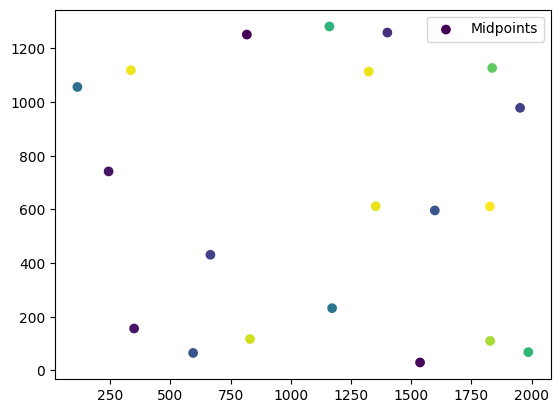

In [538]:
plt.scatter(midpoints_x, midpoints_y, c=confidences, label='Midpoints')
plt.legend()

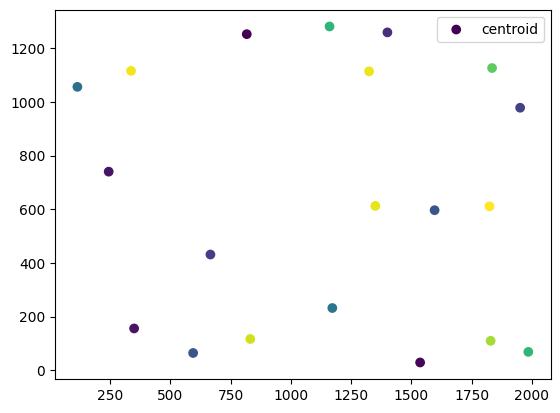

In [539]:
plt.scatter(centroid_x, centroid_y, c=confidences, label='centroid')
plt.legend()

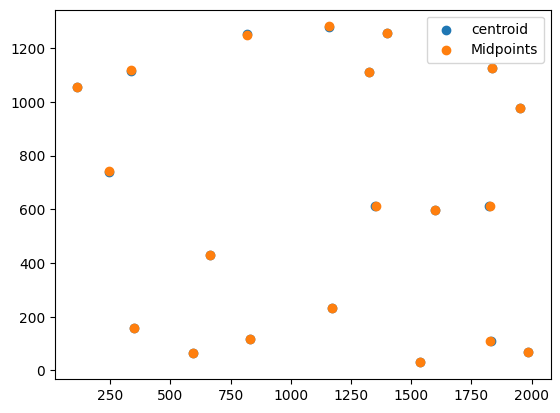

In [540]:
plt.scatter(centroid_x, centroid_y, label='centroid')
plt.scatter(midpoints_x, midpoints_y, label='Midpoints')
plt.legend()

In [541]:
import numpy as np
from scipy.fft import fft2, fftfreq, fftshift
import matplotlib.pyplot as plt
from scipy.signal import find_peaks


In [542]:
x_vals = centroid_x
y_vals = centroid_y
points = np.array([(x, y) for x, y in zip(x_vals, y_vals)])

In [543]:
x_distances = []
for x1 in x_vals:
    for x2 in x_vals:
        for p in [1]:
            if x1 != x2:
                x_distances.append(abs(x1 - x2))

(array([12.,  4.,  4.,  4.,  2.,  4.,  6.,  8.,  8.,  6.,  2., 10., 14.,
         2.,  2.,  6.,  2.,  6.,  8.,  4.,  2.,  2.,  8.,  6.,  2., 12.,
        14.,  4.,  2.,  4.,  8.,  8.,  0.,  4.,  4., 12.,  2.,  4.,  6.,
         2.,  4.,  4.,  4., 10.,  2.,  0.,  2.,  0.,  2.,  4.,  2.,  2.,
         4., 12.,  4.,  2.,  6.,  2.,  0.,  4.,  2.,  6.,  6.,  2.,  4.,
         6.,  4.,  2.,  6.,  0.,  2.,  0.,  4.,  0.,  2.,  2.,  0.,  0.,
         2., 10.,  2.,  0.,  0.,  0.,  6.,  2.,  2.,  2.,  2.,  0.,  0.,
         8.,  0.,  2.,  0.,  0.,  0.,  0.,  2.,  2.]),
 array([   4.77665548,   23.44249577,   42.10833607,   60.77417637,
          79.44001667,   98.10585697,  116.77169727,  135.43753757,
         154.10337787,  172.76921817,  191.43505846,  210.10089876,
         228.76673906,  247.43257936,  266.09841966,  284.76425996,
         303.43010026,  322.09594056,  340.76178085,  359.42762115,
         378.09346145,  396.75930175,  415.42514205,  434.09098235,
         452.75682265,  47

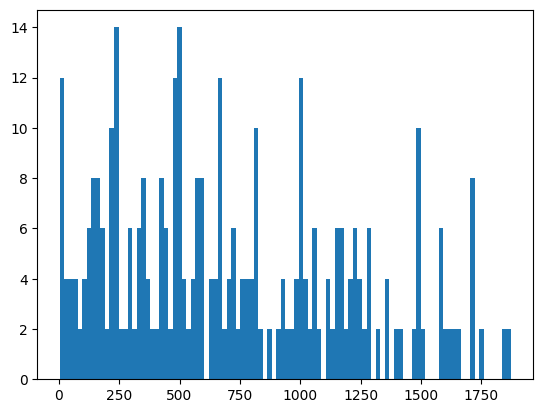

In [544]:
plt.hist(x_distances, bins=100)

In [545]:
h = np.histogram(x_distances, bins=100, density=True)

In [546]:
h

(array([0.0016918 , 0.00056393, 0.00056393, 0.00056393, 0.00028197,
        0.00056393, 0.0008459 , 0.00112787, 0.00112787, 0.0008459 ,
        0.00028197, 0.00140984, 0.00197377, 0.00028197, 0.00028197,
        0.0008459 , 0.00028197, 0.0008459 , 0.00112787, 0.00056393,
        0.00028197, 0.00028197, 0.00112787, 0.0008459 , 0.00028197,
        0.0016918 , 0.00197377, 0.00056393, 0.00028197, 0.00056393,
        0.00112787, 0.00112787, 0.        , 0.00056393, 0.00056393,
        0.0016918 , 0.00028197, 0.00056393, 0.0008459 , 0.00028197,
        0.00056393, 0.00056393, 0.00056393, 0.00140984, 0.00028197,
        0.        , 0.00028197, 0.        , 0.00028197, 0.00056393,
        0.00028197, 0.00028197, 0.00056393, 0.0016918 , 0.00056393,
        0.00028197, 0.0008459 , 0.00028197, 0.        , 0.00056393,
        0.00028197, 0.0008459 , 0.0008459 , 0.00028197, 0.00056393,
        0.0008459 , 0.00056393, 0.00028197, 0.0008459 , 0.        ,
        0.00028197, 0.        , 0.00056393, 0.  

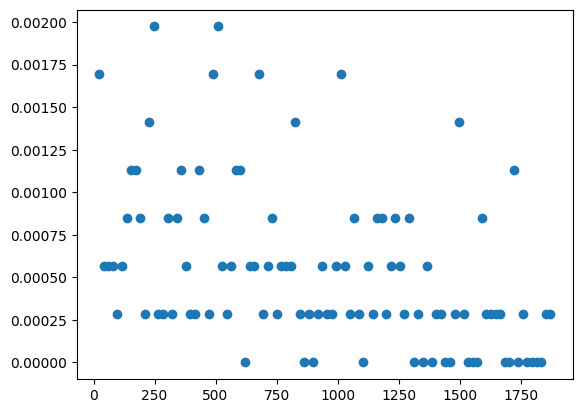

In [547]:
plt.scatter(h[1][1:], h[0])

In [548]:
denses = h[0]
vals = [(h[1][i] + h[1][i+1])/2 for i in range(len(denses))]

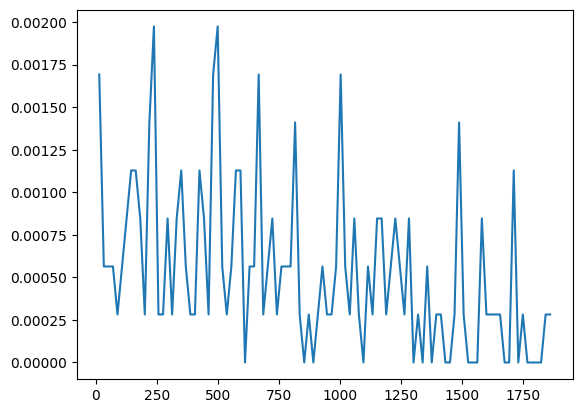

In [549]:
plt.plot(vals, denses)

In [550]:
pairs = list(zip(vals, denses))
# pairs = sorted(pairs, key=lambda x : -x[1])

In [551]:
def filter_pairs(pairs, th=2, minf=100):
    maxi = np.amax([e[1] for e in pairs if e[0]>minf])
    pairs_filetred = [p for p in pairs if p[0] > minf and p[1] > maxi/th]
    prs = pairs_filetred
    pairs_filetred2 = []
    ds = []
    for i1, pair in enumerate(prs):
        for i2, p2 in enumerate(prs):
            shrt = False
            if i1 != i2:
                if abs(pair[0] - p2[0]) < 25:
                    shrt = True

        if not shrt:
            pairs_filetred2.append(pair)

    prs = pairs_filetred2
    xs = [x[0] for x in prs]
    ys = [x[1] for x in prs]
    plt.scatter(xs, ys)
    iterations = []
    key = prs[0]
    iterations.append((key, 1))
    for i, pair in enumerate(prs):
        if i == 0:
            continue
        ober = pair[0] / key[0]
        if abs(round(ober) - ober) < 0.1:
            iterations.append((pair, round(ober)))

    freqs = []
    for i in iterations:
        f = i[0][0] / i[1]
        freqs.append(f)
    print(freqs)
    return np.average(freqs)


[144.77045771709237, 141.58602073316703, 143.5211961475298, 148.18765622223657, 143.34273020902083]


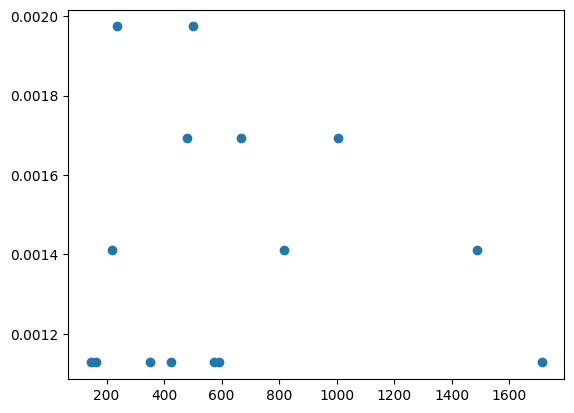

In [552]:
fx = filter_pairs(pairs)

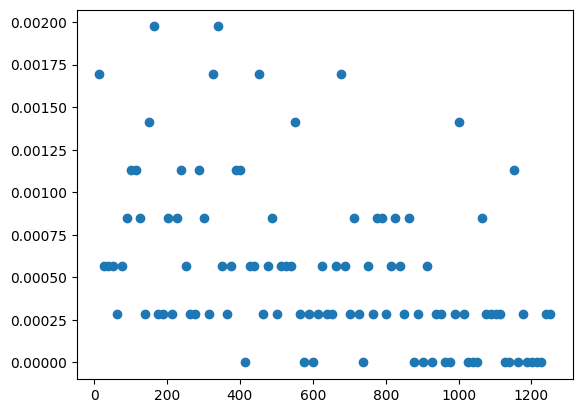

In [553]:
y_distances = []
for x1 in y_vals:
    for x2 in y_vals:
        for p in [1]:
            if x1 != x2:
                y_distances.append(abs(x1 - x2))
h2 = np.histogram(y_distances, bins=100, density=True)
plt.scatter(h2[1][1:], h[0])


In [554]:
desn_y = h2[0]
vals_y = [(h2[1][i] + h2[1][i+1])/2 for i in range(len(desn_y))]

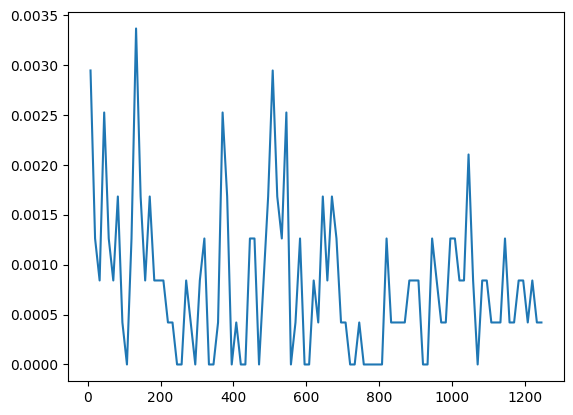

In [555]:
plt.plot(vals_y, desn_y)


In [556]:
pairs_y = list(zip(vals_y, desn_y))
# pairs_y = sorted(pairs_y, key=lambda x : -x[1])

[132.77284008952066, 130.05074621400792, 134.0351888240975]


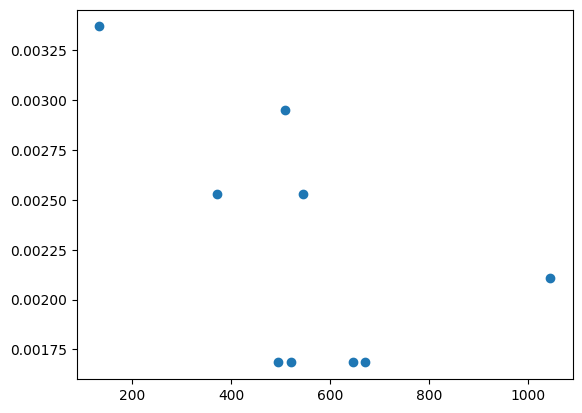

In [557]:
fy = filter_pairs(pairs_y)


In [558]:
def find_keypoint(x_vals, x_confs, fx):
    rng = np.linspace(min(x_vals), min(x_vals) + fx, 1000)
    sums = []
    for x_start in tqdm(rng):
        sum = 0
        for x2, c2 in zip(x_vals, x_confs):
            d = abs(x_start - x2)
            per = abs((x_start + (round(d/fx) * fx)) - x2)
            sum += c2 * per

        sums.append(sum)
    plt.plot(rng, sums)
    return rng[np.argmin(sums)]

100%|██████████| 1000/1000 [00:00<00:00, 46915.10it/s]


114.10206334718744

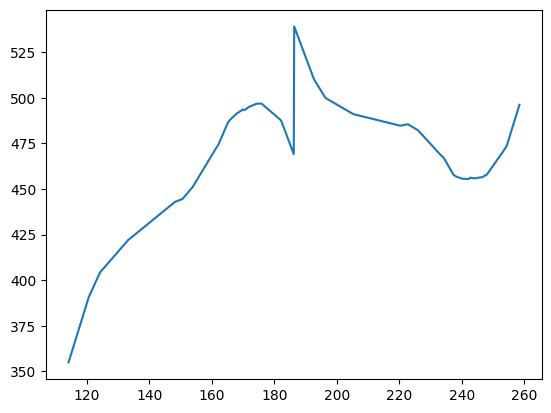

In [559]:
kpx = find_keypoint(x_vals, confidences, fx)
kpx

100%|██████████| 1000/1000 [00:00<00:00, 44106.00it/s]


68.78395833803003

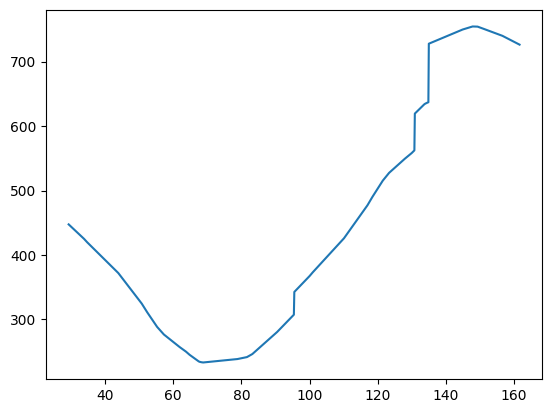

In [560]:
kpy = find_keypoint(y_vals, confidences, fy)
kpy

In [561]:
grids_y = []
for i in range(-100, 100):
    if 0 < kpy + i * fy < 1.2 * max(y_vals):
        grids_y.append( kpy + i * fy)

grids_x = []
for i in range(-100, 100):
    if 0 < kpx + i * fx < 1.2 * max(x_vals):
        grids_x.append( kpx + i * fx)

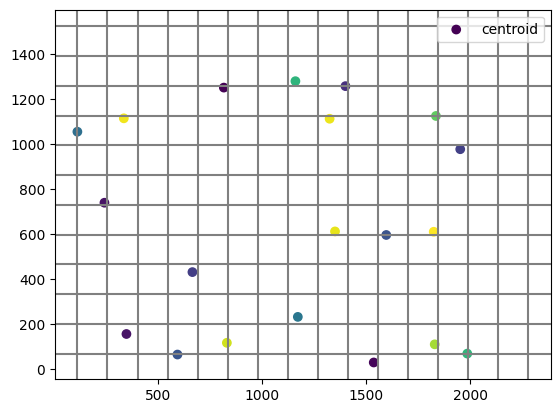

In [562]:
for gx in grids_x:
    plt.axvline(x=gx, color='gray')
for gy in grids_y:
    plt.axhline(y=gy, color='gray')
plt.scatter(centroid_x, centroid_y, c=confidences, label='centroid')
plt.legend()